<a href="https://colab.research.google.com/github/anuhingankar9922-hub/-Python-Basic-Projects/blob/main/Task_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. (Linear Regression) Find or use a dataset with a continuous target variable. Perform full preprocessing. Train a Linear Regression model. Evaluate using R² score and print predictions.

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

df=pd.read_csv("/content/insurance.csv")

print(":::::::::::::::::::::: First 5 Rows ::::::::::::::::::::::\n")
print(df.head())

X=df.drop("expenses", axis=1)
Y=df["expenses"]

numeric_col=["age","bmi","children"]
categorical_col=["sex","smoker","region"]

num_transformer=Pipeline(steps=[
    ("impute", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_transformer=Pipeline(steps=[
    ("impute",SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first"))
])

preprocessor=ColumnTransformer(transformers=[
    ("num",num_transformer,numeric_col),
    ("cat",cat_transformer,categorical_col)
])

model=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor", LinearRegression())
])

X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train,Y_train)

Y_pred=model.predict(X_test)

r2=r2_score(Y_test,Y_pred)

print("\nR2 Score:",round(r2,4))

result=pd.DataFrame({
    "Actual":Y_test.values,
    "Predicted": Y_pred
})

print("\n:- First 10 predictions -:\n")
print(result.head(10))

:::::::::::::::::::::: First 5 Rows ::::::::::::::::::::::

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

R2 Score: 0.7836

:- First 10 predictions -:

     Actual     Predicted
0   9095.07   8976.767610
1   5272.18   7061.470783
2  29330.98  36861.008380
3   9301.89   9439.167429
4  33750.29  26965.827836
5   4536.26  10866.566134
6   2117.34    163.683429
7  14210.54  16902.162539
8   3732.63   1092.788914
9  10264.44  11221.849726


Q2. (Logistic Regression) Find or use a binary classification (Categorical) dataset. Preprocess the data. Train a Logistic Regression model. Evaluate using Confusion Matrix, Accuracy, Precision, Recall, and F1 Score.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

df = pd.read_csv("/content/insurance.csv")

print(":- -:- -:- -:- -:- -:- First 5 Rows -:- -:- -:- -:- -:- -:\n")
print(df.head())

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["region"] = le.fit_transform(df["region"])
df["smoker"] = le.fit_transform(df["smoker"])

X = df.drop("smoker", axis=1)
y = df["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n_Confusion Matrix_")

print(cm)

print("\nAccuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\n-<---<<-----<<< Classification Report >>>----->>--->-\n")
print(classification_report(y_test, y_pred))

:- -:- -:- -:- -:- -:- First 5 Rows -:- -:- -:- -:- -:- -:

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

_Confusion Matrix_
[[208   6]
 [  5  49]]

Accuracy : 0.959
Precision: 0.8909
Recall   : 0.9074
F1 Score : 0.8991

-<---<<-----<<< Classification Report >>>----->>--->-

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       214
           1       0.89      0.91      0.90        54

    accuracy                           0.96       268
   macro avg       0.93      0.94      0.94       268
weighted avg       0.96      0.96      0.96       268



Q3. (KNearest Neighbors) Using a classification dataset: Train a KNearest Neighbors (KNN) model. Try different values of k (e.g., 3, 5, 7). Compare accuracy for different k values and choose the best one.

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/heart.csv")
print("._:_._:_._:_._:_._:_._:_._:_._:_. First 5 Rows ._:_._:_._:_._:_._:_._:_._:_._:_.\n")
print(df.head())

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

k_values = [3, 5, 7]

accuracy_list = []

print("\nAccuracy for Different K Values:-")

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_list.append(accuracy)

    print(f"K = {k} --> Accuracy = {accuracy:.4f}")

best_k = k_values[np.argmax(accuracy_list)]

print("\nBest K Value =", best_k)

final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train, y_train)

final_prediction = final_model.predict(X_test)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_prediction))

print("\n____:____:____:-Classification Report-:____:____:____\n")
print(classification_report(y_test, final_prediction))

print("\n-:-Final Accuracy-:-")
print(accuracy_score(y_test, final_prediction))

._:_._:_._:_._:_._:_._:_._:_._:_. First 5 Rows ._:_._:_._:_._:_._:_._:_._:_._:_.

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Accuracy for Different K Values:-
K = 3 --> Accuracy = 0.8641
K = 5 --> Accuracy = 0.8533
K = 7 --> Accuracy = 0.8967

Best 

Q4. (Naive Bayes) Using a classification dataset: Train a Naive Bayes model. Evaluate the model using classification report and confusion matrix.

_ -:- _ -:- _ -:- _ -:- _ -:- _ First 5 Row _ -:- _ -:- _ -:- _ -:- _ -:- _

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980           

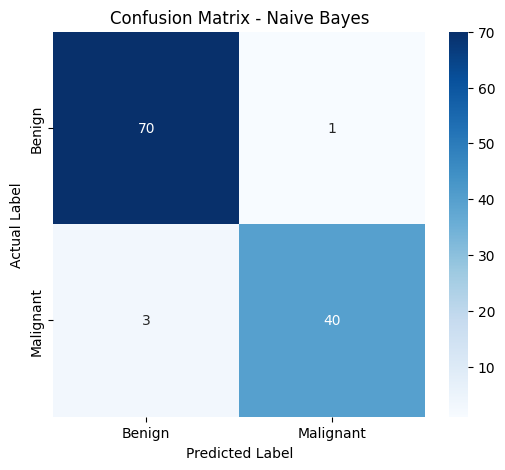

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/content/data.csv")

print("_ -:- _ -:- _ -:- _ -:- _ -:- _ First 5 Row _ -:- _ -:- _ -:- _ -:- _ -:- _\n")
print(df.head())

print("\nDataset Shape:-", df.shape)

df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print("\nMissing Values:-")
print(df.isnull().sum())

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:-", round(accuracy, 4))

print("\n-:----:----:--- Classification Report ---:----:----:-")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:-")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Q5.(Algorithm Comparison) On the same classification dataset, train and compare: Logistic Regression ,KNN, Naive Bayes. Create a comparison table showing Accuracy, Precision, Recall, and F1 Score for each algorithm. Write which algorithm performed best and why.

In [11]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("/content/data.csv")

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df.drop("diagnosis", axis=1)
Y = df["diagnosis"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)

    results.append([name, accuracy, precision, recall, f1])

comparison = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"]
)

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print("\n~:~:~:~:~:~:~:~:~:~< Algorithm Comparison >~:~:~:~:~:~:~:~:~:~\n")
print(comparison.round(4))


~:~:~:~:~:~:~:~:~:~< Algorithm Comparison >~:~:~:~:~:~:~:~:~:~

             Algorithm  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9649     0.9750  0.9286    0.9512
1                  KNN    0.9561     0.9744  0.9048    0.9383
2          Naive Bayes    0.9211     0.9231  0.8571    0.8889
